# Basketball backboard sensors: spectrograms and class-separating features

Tri-axial accelerometers on the backboard; this notebook uses **physical sensor 1 only** when `SENSOR_1_ONLY = True` (default below). Labels come from each `* - Segmented` folder. Each CSV yields **one** feature row: **peak-centered `WIN_SEC`** window, then features (same pipeline for all classes).

**Force / amplitude:** Features are **scale-free** with respect to impact strength: we do **not** use RMS acceleration, raw jerk, or spectra of `‖a‖`. Instead we use **direction** of the acceleration (unit vectors) and **direction-change** spectra plus a correlation cue, so light vs hard goaltends that share the same motion pattern are treated similarly.

Helpers: package `goaltend_close_call` (`sensor_io`, `spectrogram_features`).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import signal
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedGroupKFold, StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.base import clone

_cwd = Path.cwd().resolve()
REPO_ROOT = _cwd if (_cwd / "src").is_dir() else _cwd.parent
DATA_ROOT = REPO_ROOT / "data"
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from goaltend_close_call.sensor_io import (
    crop_peak_window,
    discover_segmented_folders,
    estimate_fs,
    load_recording_csv,
)
from goaltend_close_call.spectrogram_features import extract_features

WIN_SEC = 1.0
NPERSEG = 256
SENSOR_1_ONLY = True  # training + all feature extraction use physical sensor 1 only

META_COLS = {"path", "class", "goaltend_style", "n_samples_window"}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 4)

In [2]:
def goaltend_sublabel(path: Path) -> str:
    name = path.stem.lower()
    if "light" in name:
        return "light"
    if "hard" in name:
        return "hard"
    return "other"


def load_features_table(win_sec: float = WIN_SEC) -> pd.DataFrame:
    recs = []
    for folder, label in discover_segmented_folders(DATA_ROOT):
        if folder.name == "Other Data - Segmented":
            continue
        for csv_path in sorted(folder.glob("*.csv")):
            sub = goaltend_sublabel(csv_path) if label == "goaltends" else ""
            t, a1, a2 = load_recording_csv(csv_path, sensor_1_only=SENSOR_1_ONLY)
            fs = estimate_fs(t)
            t, a1, a2 = crop_peak_window(
                t, a1, a2, win_sec=win_sec, fs=fs, sensor_1_only=SENSOR_1_ONLY
            )
            feat = extract_features(
                t, a1, a2, fs=fs, nperseg=NPERSEG, sensor_1_only=SENSOR_1_ONLY
            )
            feat["path"] = csv_path.name
            feat["class"] = label
            feat["goaltend_style"] = sub
            feat["n_samples_window"] = len(t)
            recs.append(feat)
    return pd.DataFrame(recs)


df = load_features_table()
df.head()

,dirchg_s1_spec_centroid_hz,dirchg_s1_spec_spread_hz,dirchg_s1_spec_low_frac,dirchg_s1_spec_mid_frac,dirchg_s1_spec_high_frac,dirchg_s1_spec_rolloff_hz,dirchg_s1_spec_peak_hz,path,class,goaltend_style,n_samples_window
0,68.033932,98.875816,0.595331,0.144081,0.260588,232.124100,0.0,ball_on_rim_1_event_01.csv,ball_on_rim,,600
1,57.489500,91.283577,0.646674,0.125502,0.227824,189.919718,0.0,ball_on_rim_1_event_02.csv,ball_on_rim,,600
2,57.392690,94.192143,0.675160,0.093923,0.230916,203.987845,0.0,ball_on_rim_1_event_03.csv,ball_on_rim,,600
3,58.982147,87.031915,0.606542,0.142624,0.250834,166.472839,0.0,ball_on_rim_1_event_04.csv,ball_on_rim,,600
4,80.248140,98.139632,0.507313,0.155273,0.337413,222.745348,0.0,ball_on_rim_1_event_05.csv,ball_on_rim,,600


In [3]:
print("Samples per class:")
print(df["class"].value_counts())
print("\nGoaltend sub-types:", df[df["class"] == "goaltends"]["goaltend_style"].value_counts().to_dict())

Samples per class:
class
goaltends            52
hand_on_backboard    20
blocks               15
ball_on_rim          14
Name: count, dtype: int64

Goaltend sub-types: {'light': 27, 'hard': 25}


## Spectrogram examples (combined magnitude)

One example file per class; **peak-centered** `WIN_SEC` crop applied before the STFT.

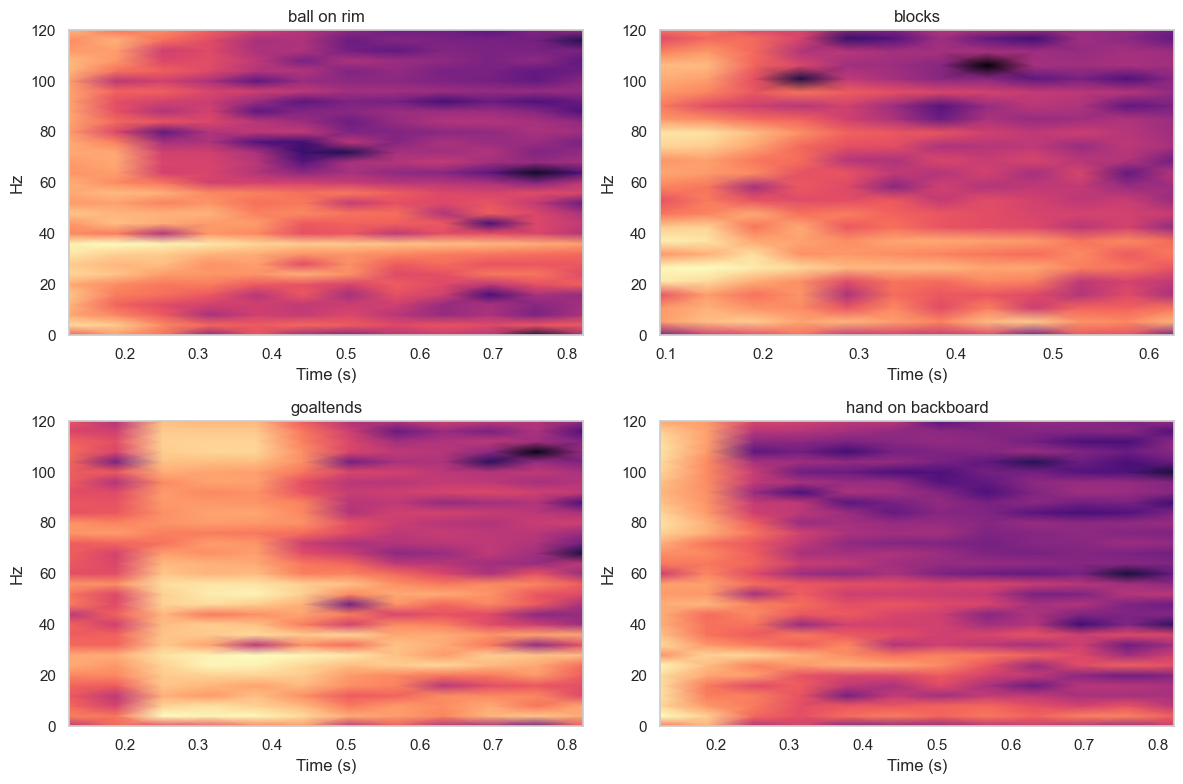

In [4]:
def plot_spectrogram_example(csv_path: Path, title: str, ax):
    t, a1, a2 = load_recording_csv(csv_path, sensor_1_only=SENSOR_1_ONLY)
    fs = estimate_fs(t)
    t, a1, a2 = crop_peak_window(
        t, a1, a2, win_sec=WIN_SEC, fs=fs, sensor_1_only=SENSOR_1_ONLY
    )
    mag = np.linalg.norm(a1, axis=1)
    if not SENSOR_1_ONLY:
        mag = mag + np.linalg.norm(a2, axis=1)
    mag = mag - np.mean(mag)
    nper = min(NPERSEG, max(len(mag) // 4, 8))
    nov = min(nper * 3 // 4, max(0, len(mag) // 2 - 1))
    f, tt, Sxx = signal.spectrogram(mag, fs, nperseg=nper, noverlap=nov, scaling="density")
    ax.pcolormesh(tt, f, 10 * np.log10(Sxx + 1e-20), shading="gouraud", cmap="magma")
    ax.set_ylim(0, min(120, f.max()))
    ax.set_ylabel("Hz")
    ax.set_xlabel("Time (s)")
    ax.set_title(title)


examples = []
for folder, label in discover_segmented_folders(DATA_ROOT):
    if folder.name == "Other Data - Segmented":
        continue
    csvs = sorted(folder.glob("*.csv"))
    if not csvs:
        continue
    examples.append((csvs[0], label))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (pth, lab) in zip(np.ravel(axes), examples):
    plot_spectrogram_example(pth, lab.replace("_", " "), ax)
plt.tight_layout()
plt.show()

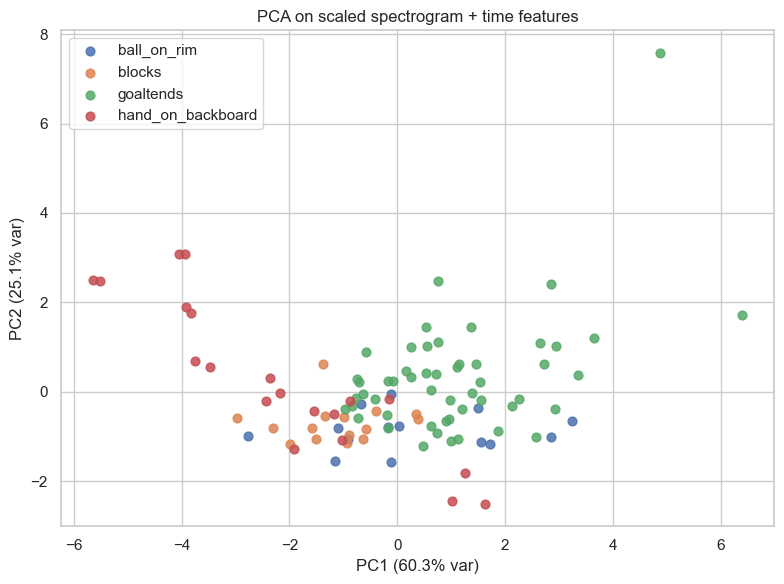

In [5]:
feat_cols = [c for c in df.columns if c not in META_COLS]
X = df[feat_cols].values
y_multi = df["class"].values
y_binary = np.where(df["class"] == "goaltends", "goaltend", "legal")

scaler = StandardScaler()
Xz = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=0)
xy = pca.fit_transform(Xz)

fig, ax = plt.subplots(figsize=(8, 6))
for lab in np.unique(y_multi):
    m = y_multi == lab
    ax.scatter(xy[m, 0], xy[m, 1], label=lab, alpha=0.85, s=40)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("PCA on scaled spectrogram + time features")
ax.legend()
plt.tight_layout()
plt.show()

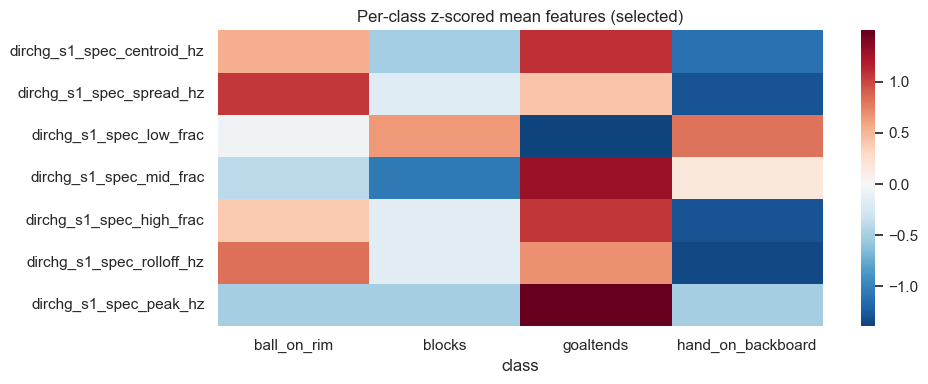

In [6]:
# Heatmap: class means of a few readable features
if SENSOR_1_ONLY:
    show = [c for c in feat_cols if "dirchg_s1" in c][:10]
else:
    show = [c for c in feat_cols if "dirchg_sum" in c or c == "dirchg_corr_s1_s2"]
z = df.groupby("class")[show].mean()
z_norm = (z - z.mean(axis=0)) / (z.std(axis=0) + 1e-9)
plt.figure(figsize=(10, 4))
sns.heatmap(z_norm.T, cmap="RdBu_r", center=0)
plt.title("Per-class z-scored mean features (selected)")
plt.tight_layout()
plt.show()

In [7]:
# Random Forest feature importances (multi-class)
rf = RandomForestClassifier(n_estimators=300, random_state=0)
rf.fit(Xz, y_multi)
imp = pd.Series(rf.feature_importances_, index=feat_cols).sort_values(ascending=False)

print("Feature importances (top 15):")
print(imp.head(15).to_string())

Feature importances (top 15):
dirchg_s1_spec_low_frac       0.216559
dirchg_s1_spec_centroid_hz    0.175926
dirchg_s1_spec_mid_frac       0.154304
dirchg_s1_spec_rolloff_hz     0.153744
dirchg_s1_spec_high_frac      0.149590
dirchg_s1_spec_spread_hz      0.148927
dirchg_s1_spec_peak_hz        0.000951


In [8]:
# Quick generalization check: goaltend vs legal (others merged)
_min_per_class = df["class"].value_counts().min()
_n_splits = int(min(5, max(2, _min_per_class)))
_cv = StratifiedKFold(n_splits=_n_splits, shuffle=True, random_state=0)

rf_b = RandomForestClassifier(n_estimators=300, random_state=0)
scores = cross_val_score(rf_b, Xz, y_binary, cv=_cv, scoring="accuracy")
print(f"Stratified {_n_splits}-fold accuracy goaltend vs legal: {scores.mean():.3f} +/- {scores.std():.3f}")

rf_m = RandomForestClassifier(n_estimators=300, random_state=0)
scores_m = cross_val_score(rf_m, Xz, y_multi, cv=_cv, scoring="accuracy")
print(f"Stratified {_n_splits}-fold accuracy multi-class: {scores_m.mean():.3f} +/- {scores_m.std():.3f}")
print("(Small datasets: treat scores as exploratory.)")

Stratified 5-fold accuracy goaltend vs legal: 0.820 +/- 0.108
Stratified 5-fold accuracy multi-class: 0.724 +/- 0.076
(Small datasets: treat scores as exploratory.)


## Retrain with labeled close calls and evaluate on unseen close calls\n
\n
Uses `close_calls_labels.csv` from your ground-truth table. `cant_tell` rows are excluded from supervised training/evaluation.\n

In [9]:
labels_path = DATA_ROOT / "close_calls_labels.csv"
close_dir = DATA_ROOT / "Close Calls"
labels = pd.read_csv(labels_path)
labels["ground_truth"] = labels["ground_truth"].str.lower().str.strip()
labels = labels[labels["ground_truth"].isin(["legal", "goaltend"])].copy()
print("Usable close-call labels (cant_tell dropped):", len(labels))
print(labels["ground_truth"].value_counts())

def features_for_file(csv_path: Path):
    t, a1, a2 = load_recording_csv(csv_path, sensor_1_only=SENSOR_1_ONLY)
    fs = estimate_fs(t)
    t, a1, a2 = crop_peak_window(
        t, a1, a2, win_sec=WIN_SEC, fs=fs, sensor_1_only=SENSOR_1_ONLY
    )
    return extract_features(
        t, a1, a2, fs=fs, nperseg=NPERSEG, sensor_1_only=SENSOR_1_ONLY
    )

# Build close-call feature table
cc_rows = []
for _, r in labels.iterrows():
    pth = close_dir / r["filename"]
    feat = features_for_file(pth)
    feat["filename"] = r["filename"]
    feat["y"] = r["ground_truth"]
    cc_rows.append(feat)
df_cc = pd.DataFrame(cc_rows)

# Hold out unseen close calls (stratified)
test_size = 3 if len(df_cc) >= 6 else max(1, int(round(0.33 * len(df_cc))))
train_cc, test_cc = train_test_split(
    df_cc,
    test_size=test_size,
    random_state=42,
    stratify=df_cc["y"],
)
print("\nClose-call split -> train:", len(train_cc), "test:", len(test_cc))

# Baseline training set from existing segmented folders (exclude Other Data)
base_rows = []
for folder, label in discover_segmented_folders(DATA_ROOT):
    if folder.name == "Other Data - Segmented":
        continue
    for csv_path in sorted(folder.glob("*.csv")):
        feat = features_for_file(csv_path)
        feat["y"] = "goaltend" if label == "goaltends" else "legal"
        base_rows.append(feat)
df_base = pd.DataFrame(base_rows)

# Retrain on base + training close calls
df_train_all = pd.concat([df_base, train_cc.drop(columns=["filename"])], ignore_index=True)
feature_cols = sorted([c for c in df_train_all.columns if c != "y"])
X_train = df_train_all[feature_cols].values
y_train = df_train_all["y"].values
X_test = test_cc[feature_cols].values
y_test = test_cc["y"].values

sc = StandardScaler()
X_train_z = sc.fit_transform(X_train)
X_test_z = sc.transform(X_test)

clf = RandomForestClassifier(n_estimators=300, random_state=0)
clf.fit(X_train_z, y_train)
pred = clf.predict(X_test_z)
proba = clf.predict_proba(X_test_z)
cls = list(clf.classes_)

print("\nUnseen close-call test accuracy:", round(accuracy_score(y_test, pred), 3))
print("\nClassification report (close-call holdout):")
print(classification_report(y_test, pred, digits=3))
print("Confusion matrix [rows=true, cols=pred] in class order", cls)
print(confusion_matrix(y_test, pred, labels=cls))

out = test_cc[["filename", "y"]].copy()
out["pred"] = pred
if "goaltend" in cls:
    out["P_goaltend"] = proba[:, cls.index("goaltend")]
if "legal" in cls:
    out["P_legal"] = proba[:, cls.index("legal")]
print("\nHeld-out close-call trial predictions:")
print(out.sort_values("filename").to_string(index=False))


Usable close-call labels (cant_tell dropped): 9
ground_truth
legal       6
goaltend    3
Name: count, dtype: int64

Close-call split -> train: 6 test: 3

Unseen close-call test accuracy: 0.667

Classification report (close-call holdout):
              precision    recall  f1-score   support

    goaltend      0.000     0.000     0.000         1
       legal      0.667     1.000     0.800         2

    accuracy                          0.667         3
   macro avg      0.333     0.500     0.400         3
weighted avg      0.444     0.667     0.533         3

Confusion matrix [rows=true, cols=pred] in class order ['goaltend', 'legal']
[[0 1]
 [0 2]]

Held-out close-call trial predictions:
          filename        y  pred  P_goaltend  P_legal
close_calls_10.csv    legal legal    0.336667 0.663333
 close_calls_3.csv    legal legal    0.420000 0.580000
 close_calls_8.csv goaltend legal    0.026667 0.973333


/Users/ruoqianzhu/Desktop/data/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/ruoqianzhu/Desktop/data/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/ruoqianzhu/Desktop/data/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

## Repeated stratified and grouped evaluation

- **Repeated stratified CV**: robust estimate over many random stratified folds.
- **Grouped CV**: keeps related samples together using a filename-family group id (`*_event_*` -> family) to reduce leakage.


In [10]:
# Binary labels for the main dataset
y_bin = np.where(df["class"] == "goaltends", "goaltend", "legal")

# Repeated stratified CV on full dataset
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=42)
rf_eval = RandomForestClassifier(n_estimators=300, random_state=0)
scores_rep = cross_val_score(rf_eval, Xz, y_bin, cv=rskf, scoring="accuracy")
print(f"Repeated stratified CV (5x20={len(scores_rep)} folds): {scores_rep.mean():.3f} +/- {scores_rep.std():.3f}")

# Build groups from filename family to avoid leakage across related trials
def trial_group_id(name: str) -> str:
    stem = Path(name).stem
    if "_event_" in stem:
        return stem.split("_event_")[0]
    return stem

groups = df["path"].astype(str).map(trial_group_id).values
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

scores_group = []
for tr_idx, te_idx in sgkf.split(X, y_bin, groups=groups):
    Xtr, Xte = X[tr_idx], X[te_idx]
    ytr, yte = y_bin[tr_idx], y_bin[te_idx]
    sc = StandardScaler()
    Xtrz = sc.fit_transform(Xtr)
    Xtez = sc.transform(Xte)
    m = clone(rf_eval)
    m.fit(Xtrz, ytr)
    scores_group.append((m.predict(Xtez) == yte).mean())

scores_group = np.array(scores_group)
print(f"Stratified grouped CV (5 folds): {scores_group.mean():.3f} +/- {scores_group.std():.3f}")
print("Grouped fold accuracies:", np.round(scores_group, 3))


Repeated stratified CV (5x20=100 folds): 0.831 +/- 0.075
Stratified grouped CV (5 folds): 0.800 +/- 0.079
Grouped fold accuracies: [0.762 0.952 0.8   0.737 0.75 ]
